In [44]:
# HII coords
import pandas as pd
hii = pd.read_csv("bica.csv")

hii.rename(columns={'RAJ2000': 'RA', 'DEJ2000' : 'DEC'}, inplace=True)

cols = ["RA", "DEC"]
hii[cols]

coords = hii

In [47]:
from astropy.coordinates import SkyCoord
import astropy.units as u

snr = SkyCoord("05h47m50s", "-70d24m45s", frame="icrs")
regions = SkyCoord(coords["RA"].values * u.deg, coords["DEC"].values * u.deg, frame="icrs")

regions

<SkyCoord (ICRS): (ra, dec) in deg
    [(32.20833333, -74.91666667), (31.96666667, -74.73555556),
     (33.66666667, -74.35666667), ..., (15.29166667, -71.47027778),
     (14.6125    , -71.49333333), (27.02916667, -69.48888889)]>

In [49]:
sep = snr.separation(regions)

fov = coords[sep < 10 * u.arcmin]

fov

,recno,Names,RA,DEC,Type,amaj,amin,PA,Com,SimbadName
211,1422,SNR0548-70.4,86.958333,-70.414444,SNR,1.7,1.7,NaN,,SNR0548-70.4


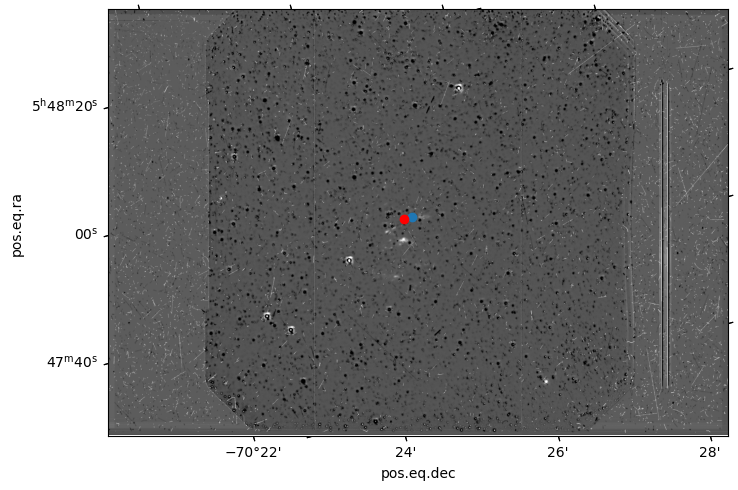

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

image = fits.open("test_sub6.fits")[0].data
wcs_hdul = fits.open("images/SNR_OIII.fits")

wcs = WCS(wcs_hdul["SCI"].header)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

ax.imshow(image, origin="lower", cmap="gray", vmin=np.percentile(image,1), vmax=np.percentile(image,99.5))

ax.scatter(fov["RA"].values *u.deg, fov["DEC"].values *u.deg, transform=ax.get_transform("world"))

ax.scatter(snr.ra, snr.dec, color="r", transform=ax.get_transform("world"))